# Latihan Mandiri Tugas Praktikum #1

**Nama : Dwi Sonnia Rahmadani**

**NIM : 2411511017**

**Mata Kuliah : Pemrosesan Paralel**



## 1. Klasifikasi Flynn

Klasifikasi ditentukan dari jumlah **aliran instruksi** dan **aliran data** yang diproses secara bersamaan.

| Skenario | Kategori | Alasan |
|---|---|---|
| `arr + arr` pada NumPy array | **SIMD** | Satu operasi/instruksi vektor diterapkan ke banyak elemen data sekaligus. |
| Program Python biasa tanpa threading/multiprocessing yang membaca file lalu memproses baris demi baris | **SISD** | Instruksi dieksekusi secara sekuensial terhadap data secara berurutan. |
| Cluster komputer dengan tiap node menjalankan simulasi cuaca berbeda secara independen | **MIMD** | Banyak node dapat menjalankan instruksi/program berbeda terhadap data yang berbeda secara bersamaan. |

**Catatan penting:** klasifikasi Flynn bergantung pada implementasi konkret. Istilah “threading/multiprocessing” saja belum cukup menentukan kategori, yang menentukan adalah pola instruksi dan datanya.

## 2. Analisis Hukum Amdahl

Diberikan proporsi program yang dapat diparalelkan **P = 0.85**. Hukum Amdahl:

$$S(N)=\frac{1}{(1-P)+\frac{P}{N}}$$

Pada bagian ini kita menggunakan fungsi `amdahl_speedup(P, N)` seperti pada notebook materi.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def amdahl_speedup(P, N):
    return 1 / ((1 - P) + P / N)

P = 0.85
N_values = [2, 4, 8, 16, 32, 64]

speedups = [amdahl_speedup(P, N) for N in N_values]

df_amdahl = pd.DataFrame({
    'N (Jumlah Prosesor)': N_values,
    'Speedup Teoritis': speedups
})

df_amdahl

,N (Jumlah Prosesor),Speedup Teoritis
0,2,1.739130
1,4,2.758621
2,8,3.902439
3,16,4.923077
4,32,5.663717
5,64,6.124402


### Hasil perhitungan

Nilai speedup teoritis yang diperoleh adalah sekitar:

- N = 2 → **1.74×**
- N = 4 → **2.76×**
- N = 8 → **3.90×**
- N = 16 → **4.92×**
- N = 32 → **5.66×**
- N = 64 → **6.12×**

Batas maksimum saat jumlah prosesor menuju tak hingga adalah:

$$S_{max}=\frac{1}{1-P}=\frac{1}{0.15}\approx 6.67$$

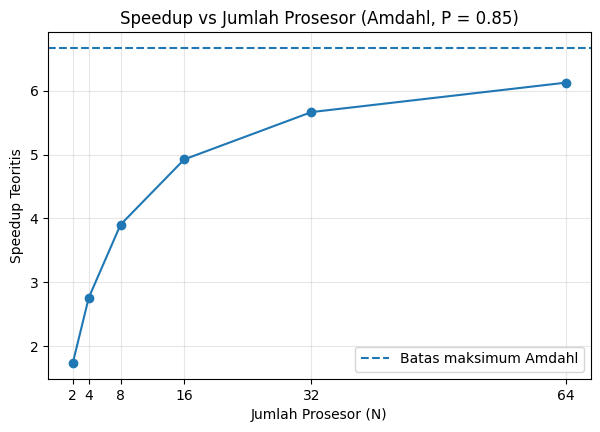

In [2]:
plt.figure(figsize=(7, 4.5))
plt.plot(N_values, speedups, marker='o')
plt.axhline(1/(1-P), linestyle='--', label='Batas maksimum Amdahl')
plt.xlabel('Jumlah Prosesor (N)')
plt.ylabel('Speedup Teoritis')
plt.title('Speedup vs Jumlah Prosesor (Amdahl, P = 0.85)')
plt.xticks(N_values)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

### Diminishing returns

Penambahan prosesor mulai memberikan manfaat yang jauh lebih kecil setelah sekitar **N = 16**. Dari 8 → 16 prosesor, speedup bertambah sekitar 1.02×, sedangkan 32 → 64 hanya bertambah sekitar 0.46×. Penyebabnya adalah bagian serial sebesar **15%** tidak ikut diparalelkan, sehingga semakin banyak prosesor ditambahkan, kontribusi bagian paralel semakin mendekati batas dan kurva menjadi jenuh.

**Catatan:** angka N = 16 dipakai sebagai titik praktis untuk menjelaskan mulai terlihatnya diminishing returns; secara matematis, penurunan manfaat berlangsung bertahap, bukan pada satu titik cutoff yang mutlak.

## 3. Benchmark Mandiri: `time.perf_counter()` vs `timeit`

Fungsi yang digunakan adalah fungsi CPU-bound sederhana untuk menghitung banyak bilangan prima di bawah `n`. Fungsi ini dibuat dari pola `hitung_prima()` pada materi, lalu dipakai untuk empat ukuran input yang berbeda.

Pada `timeit`, setiap ukuran input diukur beberapa kali (`repeat=5`) dan nilai terbaik digunakan sebagai waktu benchmark utama. `perf_counter()` digunakan untuk satu pengukuran langsung.

In [3]:
import time
import timeit

def hitung_prima(n):
    primes = []
    for num in range(2, n):
        is_prime = True
        for i in range(2, int(num ** 0.5) + 1):
            if num % i == 0:
                is_prime = False
                break
        if is_prime:
            primes.append(num)
    return primes

# Empat ukuran input berbeda
ukuran_input = [10_000, 20_000, 40_000, 80_000]

hasil = []

for n in ukuran_input:
    # Pengukuran dengan perf_counter()
    start = time.perf_counter()
    hitung_prima(n)
    waktu_perf = time.perf_counter() - start

    # Pengukuran dengan timeit (5 pengulangan)
    waktu_timeit = timeit.repeat(
        stmt='hitung_prima(n)',
        globals={'hitung_prima': hitung_prima, 'n': n},
        number=1,
        repeat=5
    )
    waktu_terbaik = min(waktu_timeit)
    waktu_rata2 = sum(waktu_timeit) / len(waktu_timeit)

    hasil.append({
        'Input N': n,
        'perf_counter (detik)': waktu_perf,
        'timeit terbaik (detik)': waktu_terbaik,
        'timeit rata-rata (detik)': waktu_rata2
    })

df_benchmark = pd.DataFrame(hasil)
df_benchmark

,Input N,perf_counter (detik),timeit terbaik (detik),timeit rata-rata (detik)
0,10000,0.015063,0.014529,0.015181
1,20000,0.037181,0.035734,0.036217
2,40000,0.087599,0.085989,0.098706
3,80000,0.243522,0.256114,0.376464


### Perbandingan hasil

Hasil waktu dapat sedikit berbeda pada setiap komputer atau runtime Colab karena dipengaruhi CPU, beban sistem, dan kondisi lingkungan eksekusi. Karena itu, yang lebih penting adalah melihat **pola pertumbuhan waktu** saat ukuran input bertambah.

`time.perf_counter()` cocok untuk mengukur satu eksekusi secara langsung, sedangkan `timeit` lebih cocok untuk benchmarking karena menjalankan kode berkali-kali dan memberikan beberapa hasil pengukuran.

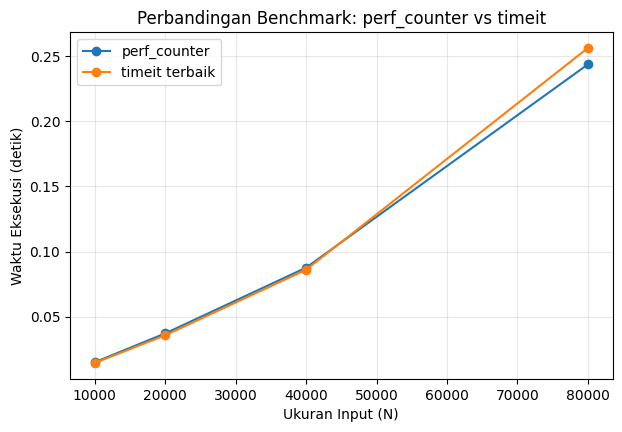

In [4]:
plt.figure(figsize=(7, 4.5))
plt.plot(df_benchmark['Input N'], df_benchmark['perf_counter (detik)'], marker='o', label='perf_counter')
plt.plot(df_benchmark['Input N'], df_benchmark['timeit terbaik (detik)'], marker='o', label='timeit terbaik')
plt.xlabel('Ukuran Input (N)')
plt.ylabel('Waktu Eksekusi (detik)')
plt.title('Perbandingan Benchmark: perf_counter vs timeit')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

Berdasarkan grafik, waktu eksekusi meningkat seiring bertambahnya ukuran input dari 10.000 hingga 80.000. Hal ini menunjukkan bahwa fungsi yang diuji memiliki beban kerja CPU-bound, sehingga input yang lebih besar membutuhkan waktu pemrosesan lebih lama.
Hasil pengukuran menggunakan perf_counter dan timeit menunjukkan pola yang hampir sama. Nilai keduanya relatif berdekatan pada ukuran input kecil hingga sedang, sedangkan pada input 80.000 terdapat sedikit perbedaan. Metode timeit menghasilkan waktu terbaik sekitar 0,257 detik, sementara perf_counter mencatat sekitar 0,244 detik. Perbedaan tersebut dapat disebabkan oleh variasi beban sistem, proses latar belakang, dan cara pengukuran yang berbeda.
Secara keseluruhan, kedua metode dapat digunakan untuk mengukur waktu eksekusi, tetapi timeit lebih sesuai untuk benchmark karena melakukan pengulangan pengukuran dan membantu mengurangi pengaruh gangguan sementara pada sistem

## 4. Refleksi Singkat

**Jawaban:**

Hukum Amdahl lebih relevan ketika ukuran masalah tetap dan tujuan kita adalah menyelesaikan pekerjaan yang sama dengan waktu lebih cepat menggunakan lebih banyak prosesor. Contohnya, sebuah program pengolahan citra memiliki ukuran gambar tetap dan kita ingin mengurangi waktu proses dari 8 core menjadi 16 core. Dalam kondisi ini, bagian serial membatasi speedup maksimum.

Sebaliknya, Hukum Gustafson lebih relevan ketika jumlah prosesor bertambah dan ukuran masalah juga dapat diperbesar. Contohnya, pada simulasi cuaca atau analisis data berukuran besar, tambahan prosesor dapat dipakai untuk memproses lebih banyak wilayah, resolusi lebih tinggi, atau data lebih banyak dalam waktu yang relatif sama. Jadi, Amdahl menekankan **speedup untuk masalah tetap**, sedangkan Gustafson menekankan **kemampuan menyelesaikan masalah yang lebih besar ketika resource bertambah**.

## Ringkasan Jawaban

1. **Flynn:** `arr + arr` NumPy → **SIMD**; Python sekuensial → **SISD**; cluster simulasi independen → **MIMD**.
2. **Amdahl, P = 0.85:** speedup N = 2, 4, 8, 16, 32, 64 berturut-turut ≈ **1.74×, 2.76×, 3.90×, 4.92×, 5.66×, 6.12×**. Batas maksimum ≈ **6.67×**.
3. **Benchmark:** membandingkan `time.perf_counter()` dan `timeit` pada empat ukuran input menggunakan tabel dan plot.
4. **Refleksi:** Amdahl untuk ukuran masalah tetap; Gustafson untuk ukuran masalah yang ditingkatkan bersama jumlah prosesor.